In [2]:
# %pip install scikit-learn

In [3]:
#%pip install numpy
# %pip install scikit-learn

In [4]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np
import sklearn

In [5]:
IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3
EPOCHS=40


In [6]:
# dataset_path = "plantvillage"
dataset = tf.keras.preprocessing.image_dataset_from_directory(
   "dataSet",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
    )

Found 9027 files belonging to 4 classes.


In [7]:
class_name = dataset.class_names
class_name

['Black Rot', 'ESCA', 'Healthy', 'Leaf Blight']

(32, 256, 256, 3)
[1 1 2 0 3 3 0 3 0 1 1 3 0 3 2 1 1 2 1 1 1 3 0 0 2 1 1 0 2 3 1 2]


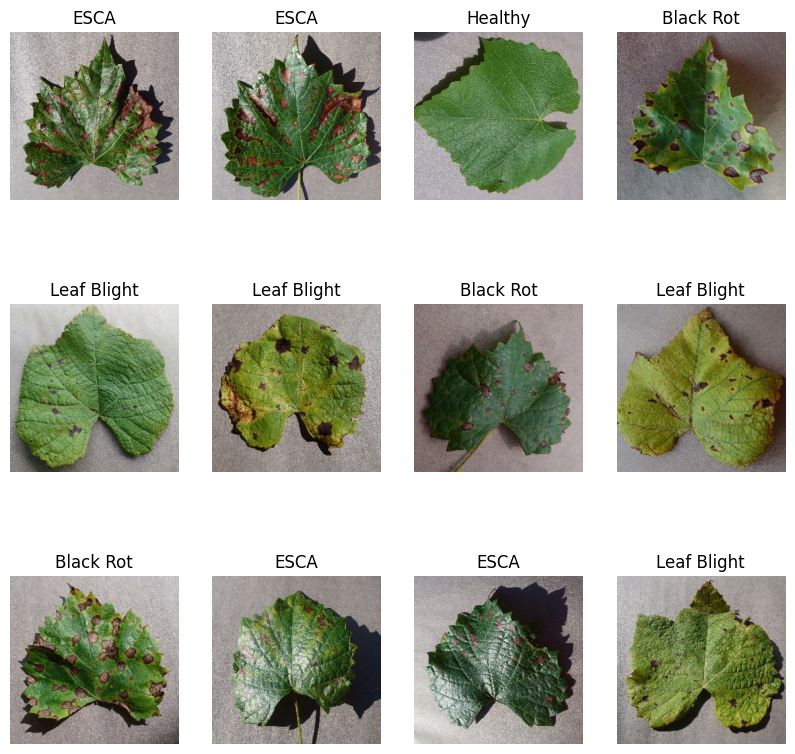

In [8]:
plt.figure(figsize=(10, 10))
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
for i in range(12):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    class_index = (labels_batch[i])
    plt.title(class_name[class_index])
    plt.axis("off")
 
# _____________

In [9]:
# 80% ==> Training
# 20% ==> test
#     10% ==> Validation
#     10% ==> Test

In [10]:
train_size= 0.8
len(dataset)*train_size

226.4

In [11]:
train_ds = dataset.take(226)
len(train_ds)

226

In [12]:
test_ds = dataset.skip(226)
len(test_ds)

57

In [13]:
val_size=0.1
len(dataset)*val_size

28.3

In [14]:
val_ds = test_ds.take(28)
len(val_ds)

28

In [15]:
test_ds= test_ds.skip(28)
len(test_ds)

29

In [16]:

def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + val_split + test_split) == 1

    # Get the size of the dataset
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds



In [17]:
train_data, val_data, test_data = get_dataset_partitions_tf(dataset)

In [18]:
len(train_ds)

226

In [19]:
len(val_ds)

28

In [20]:
len(test_ds)

29

In [21]:
300*32

9600

In [22]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [23]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch[0].numpy()/223)

[[[0.83856505 0.8206278  0.80717486]
  [0.85201794 0.8340807  0.8206278 ]
  [0.8654708  0.84753364 0.8340807 ]
  ...
  [0.5515695  0.5201794  0.49327356]
  [0.57399106 0.54260087 0.5156951 ]
  [0.50672644 0.4753363  0.44843048]]

 [[0.85201794 0.8340807  0.8206278 ]
  [0.85650223 0.83856505 0.8251121 ]
  [0.85650223 0.83856505 0.8251121 ]
  ...
  [0.5605381  0.529148   0.50224215]
  [0.5605381  0.529148   0.50224215]
  [0.51121074 0.47982064 0.4529148 ]]

 [[0.89686096 0.8789238  0.8654708 ]
  [0.88789237 0.8699552  0.85650223]
  [0.8789238  0.86098653 0.84753364]
  ...
  [0.6143498  0.58295965 0.5560538 ]
  [0.57399106 0.54260087 0.5156951 ]
  [0.5560538  0.5246637  0.49775785]]

 ...

 [[0.9013453  0.8789238  0.85201794]
  [0.9192825  0.89686096 0.8699552 ]
  [0.9103139  0.88789237 0.86098653]
  ...
  [0.6053812  0.5470852  0.51121074]
  [0.5470852  0.48878923 0.4529148 ]
  [0.5381166  0.47982064 0.44394618]]

 [[0.8744395  0.85201794 0.8251121 ]
  [0.9103139  0.88789237 0.86098653]


In [24]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/223)
]
)

In [25]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
]
)

In [26]:

input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)  # Note: Exclude batch size here
n_classes = 4

# Define the model
model = models.Sequential([
    layers.Input(shape=input_shape),  # Exclude BATCH_SIZE for input shape
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])



In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 187,972 (734.27 KB)

 Trainable params: 187,972 (734.27 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [29]:
# history = model.fit(
#     train_ds,
#     batch_size=BATCH_SIZE,
#     validation_data=val_ds,
#     verbose=1,
#     epochs=EPOCHS
# )

history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 227s 977ms/step - accuracy: 0.5931 - loss: 0.8963 - val_accuracy: 0.7824 - val_loss: 0.5449
Epoch 2/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 157s 693ms/step - accuracy: 0.8699 - loss: 0.3401 - val_accuracy: 0.6585 - val_loss: 1.1759
Epoch 3/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 146s 646ms/step - accuracy: 0.9159 - loss: 0.2207 - val_accuracy: 0.9275 - val_loss: 0.2090
Epoch 4/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 159s 702ms/step - accuracy: 0.9472 - loss: 0.1420 - val_accuracy: 0.9107 - val_loss: 0.2294
Epoch 5/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 162s 718ms/step - accuracy: 0.9549 - loss: 0.1220 - val_accuracy: 0.9609 - val_loss: 0.1158
Epoch 6/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 154s 682ms/step - accuracy: 0.9671 - loss: 0.0929 - val_accuracy: 0.9777 - val_loss: 0.0624
Epoch 7/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 156s 688ms/step - accuracy: 0.9725 - loss: 0.0780 - val_accuracy: 0.9900 - val_loss: 0.0372
Epoch 8/40
226/226 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.9683 - lo

In [30]:
len(test_ds)


29

In [31]:
scores = model.evaluate(test_ds)

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 1.0000 - loss: 0.0018


In [32]:
scores

[0.001823855796828866, 1.0]

In [33]:
history.params
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [34]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [35]:
history.history['accuracy']

[0.5930586457252502,
 0.8698838353157043,
 0.9159291982650757,
 0.9471791982650757,
 0.9549225568771362,
 0.9670907258987427,
 0.9724833965301514,
 0.9683351516723633,
 0.9752488732337952,
 0.9816095232963562,
 0.9778761267662048,
 0.9850663542747498,
 0.982162594795227,
 0.9845132827758789,
 0.9854812026023865,
 0.9795354008674622,
 0.9897676706314087,
 0.9900442361831665,
 0.988661527633667,
 0.9907355904579163,
 0.98893803358078,
 0.9910121560096741,
 0.9919800758361816,
 0.993224561214447,
 0.9946073293685913,
 0.9918417930603027,
 0.9910121560096741,
 0.9925332069396973,
 0.9940541982650757,
 0.9933628439903259,
 0.9894911646842957,
 0.9937776327133179,
 0.9950221180915833,
 0.9901825189590454,
 0.9943307638168335,
 0.9959900379180908,
 0.9936394095420837,
 0.9958517551422119,
 0.9984790086746216,
 0.9965431690216064]

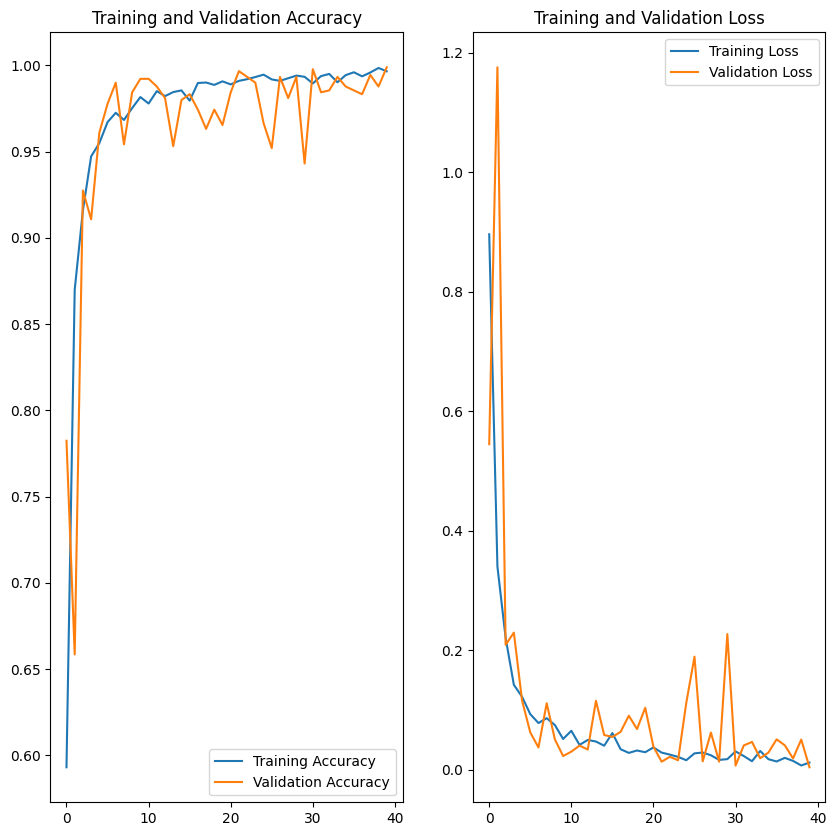

In [36]:
plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend (loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
Actual label: Healthy
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 620ms/step
Predicted label: Healthy


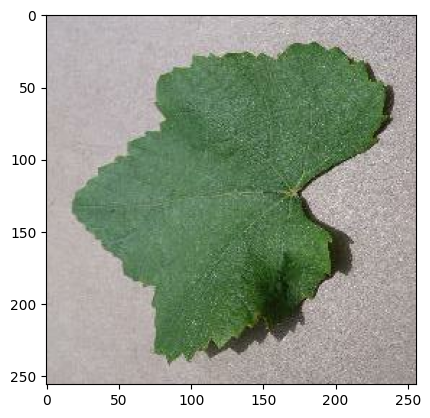

In [37]:
for images_batch, labels_batch in test_ds.take(1):
     first_image = images_batch[0].numpy().astype("uint8")
     print("first image to predict")
     plt.imshow(first_image)
     print("Actual label:", class_name[labels_batch[0].numpy()])
     batch_prediction =  model.predict(images_batch)
     print("Predicted label:",class_name[np.argmax(batch_prediction[0])])

In [38]:
# model2= keras.models.load_model("../saved_models/1sumer.keras")
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) # Create a batch
    predictions = model.predict(img_array)
    predicted_class = class_name [np.argmax (predictions[0])]
    confidence = round(100*(np.max(predictions[0])), 2)
    return predicted_class, confidence
    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


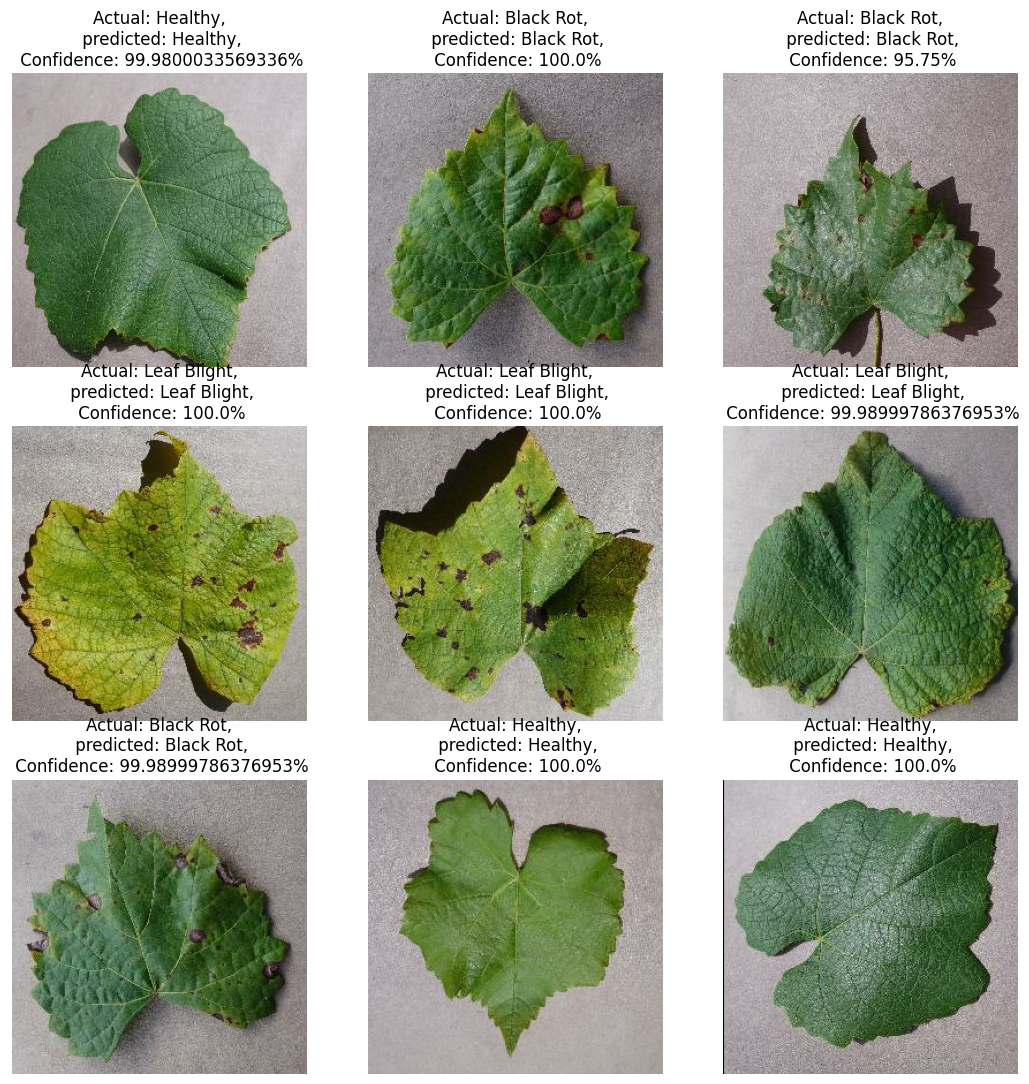

In [39]:
plt.figure(figsize=(13, 13))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        predicted_class, confidence = predict(model, images[i].numpy())
        
        actual_class = class_name[labels[i]]
        plt.title(f"Actual: {actual_class},\n predicted: {predicted_class},\n Confidence: {confidence}%")
        plt.axis("off")
        
        

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

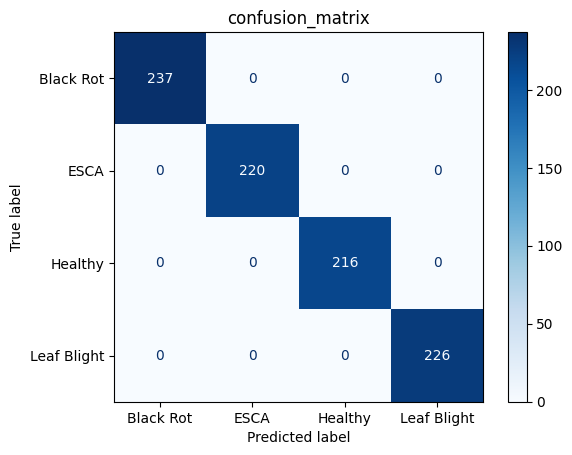

In [40]:
import tensorflow as tf
from tensorflow.keras import models, layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming the above code has been run and the model is trained, evaluated, and the datasets are defined.

# Step 1: Make predictions on the test dataset
y_true = []
y_pred = []

for images_batch, labels_batch in test_ds:
    predictions = model.predict(images_batch)
    y_true.extend(labels_batch.numpy()) ;\
    y_pred.extend(np.argmax(predictions, axis=1))

# Step 2: Compute the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Step 3: Visualize the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_name)
disp.plot(cmap=plt.cm.Blues)
plt.title("confusion_matrix")
plt.show()

In [41]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Assuming your dataset, train_ds, val_ds, and test_ds are already defined

# Function to count class occurrences in a dataset
def count_class_occurrences(dataset, class_names):
    class_counts = {class_name: 0 for class_name in class_names}
    for images, labels in dataset:
        for label in labels.numpy():
            class_counts[class_names[label]] += 1
    return class_counts

# Count class occurrences in each partition
class_names = dataset.class_names
train_class_counts = count_class_occurrences(train_ds, class_names)
val_class_counts = count_class_occurrences(val_ds, class_names)
test_class_counts = count_class_occurrences(test_ds, class_names)

# Prepare data for plotting
categories = class_names
train_counts = [train_class_counts[class_name] for class_name in class_names]
val_counts = [val_class_counts[class_name] for class_name in class_names]
test_counts = [test_class_counts[class_name] for class_name in class_names]


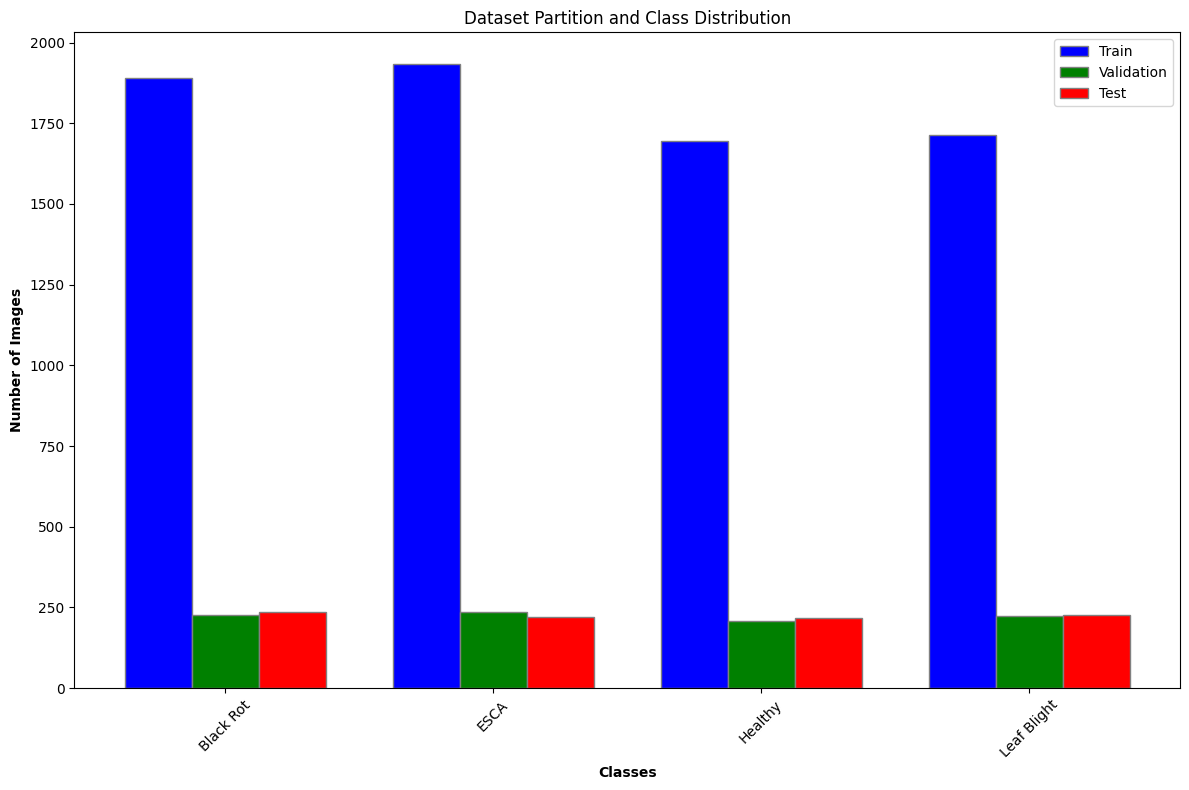

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Bar width
bar_width = 0.25

# Set position of bar on X axis
r1 = np.arange(len(train_counts))
r2 = [x + bar_width for x in r1]
r3 = [x + bar_width for x in r2]

# Make the plot
plt.figure(figsize=(12, 8))
plt.bar(r1, train_counts, color='b', width=bar_width, edgecolor='grey', label='Train')
plt.bar(r2, val_counts, color='g', width=bar_width, edgecolor='grey', label='Validation')
plt.bar(r3, test_counts, color='r', width=bar_width, edgecolor='grey', label='Test')

# Add labels
plt.xlabel('Classes', fontweight='bold')
plt.ylabel('Number of Images', fontweight='bold')
plt.xticks([r + bar_width for r in range(len(train_counts))], categories, rotation=45)
plt.title('Dataset Partition and Class Distribution')
plt.legend()

# Show plot
plt.tight_layout()
plt.show()


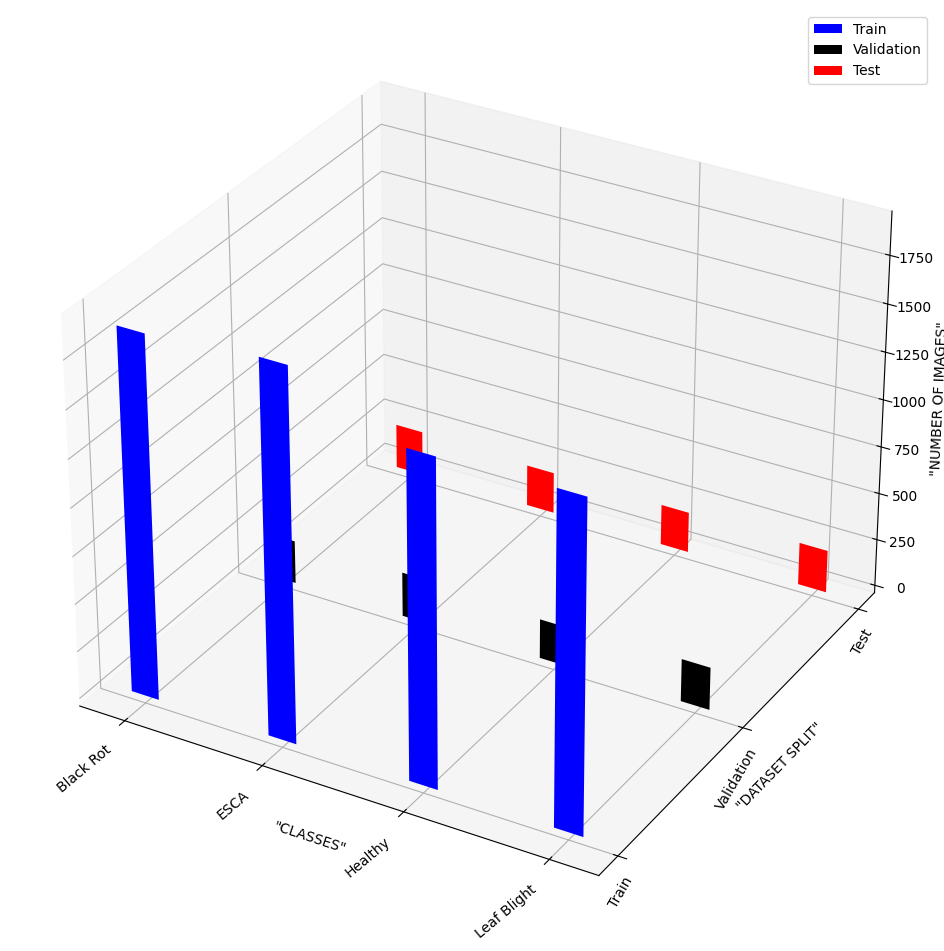

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Plotting the data in a 3D bar chart
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')

# Set the positions and width for the bars
bar_width = 0.20
x = np.arange(len(categories))
y_train = np.zeros(len(categories))
y_val = y_train + bar_width
y_test = y_val + bar_width

# Plotting
ax.bar(x, train_counts, zs=0, zdir='y', width=bar_width, color='b', alpha=1, label='Train')
ax.bar(x, val_counts, zs=1, zdir='y', width=bar_width, color='black', alpha=1, label='Validation')
ax.bar(x, test_counts, zs=2, zdir='y', width=bar_width, color='r', alpha=1, label='Test')

# Setting the labels
ax.set_xlabel('"CLASSES"')
ax.set_ylabel('"DATASET SPLIT"')
ax.set_zlabel('"NUMBER OF IMAGES"')

# Setting ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=40, ha='right')
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(['Train', 'Validation', 'Test'], rotation=60, ha='right')

# Adding a legend
ax.legend()

# Showing the plot
plt.show()


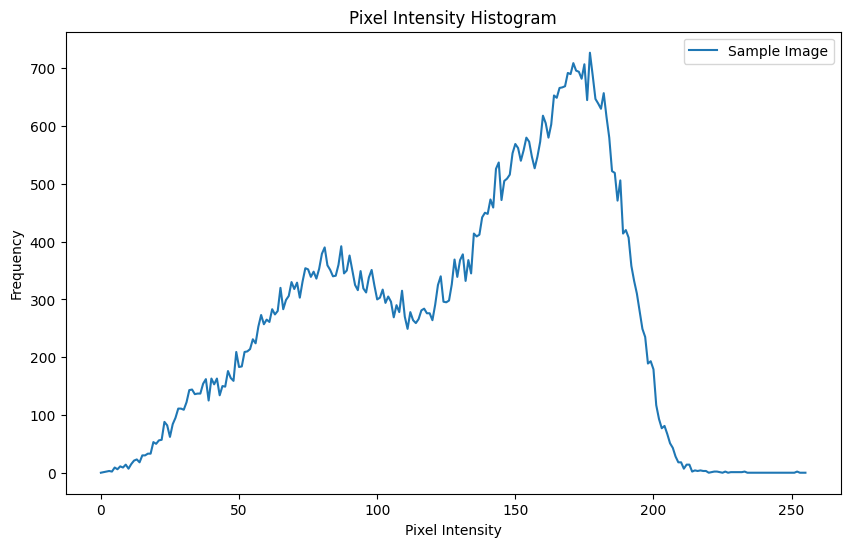

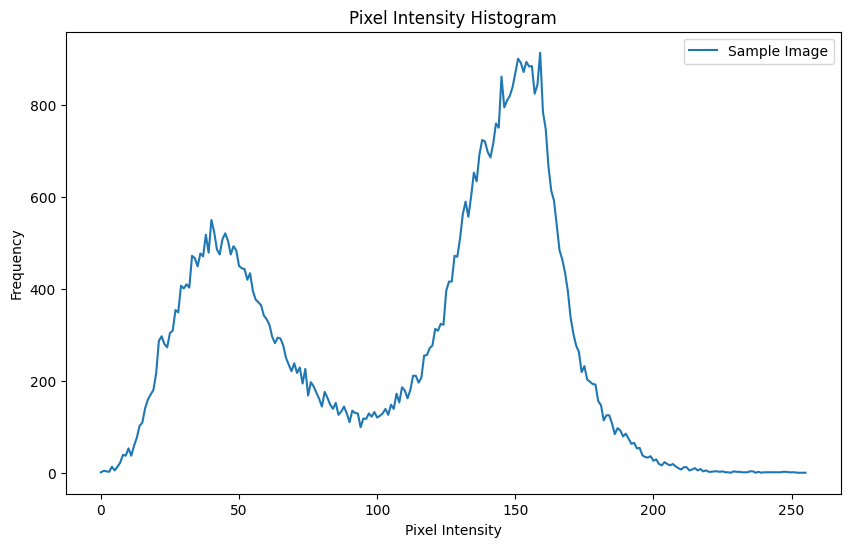

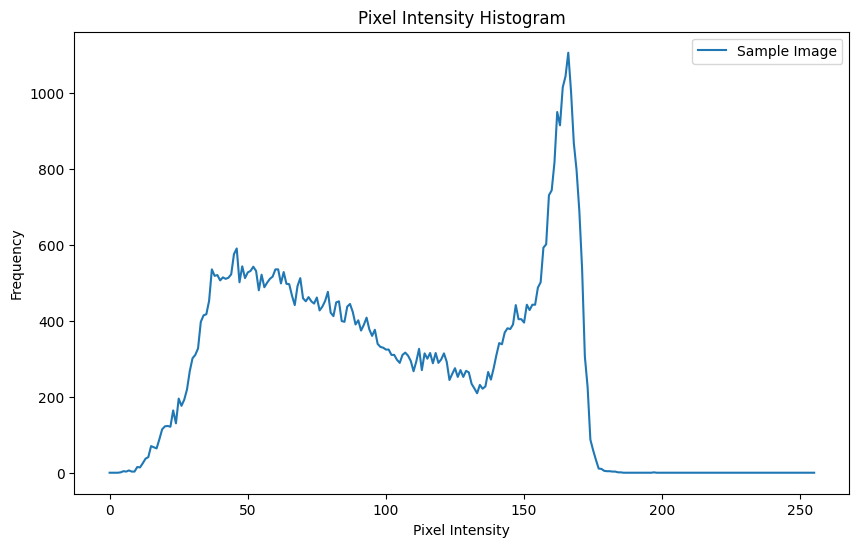

In [44]:
def plot_histogram(dataset_partition):
    plt.figure(figsize=(10, 6))
    plt.title("Pixel Intensity Histogram")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    for images, labels in dataset_partition.take(1):
        # Convert images to grayscale
        gray_images = tf.image.rgb_to_grayscale(images)

        # Compute histogram for a sample image
        hist = np.histogram(gray_images[0].numpy().flatten(), bins=256, range=[0, 256])

        # Plot histogram
        plt.plot(hist[1][:-1], hist[0], label="Sample Image")

    plt.legend()
    plt.show()

# Plot histograms for dataset partitions
plot_histogram(train_data)
plot_histogram(val_data)
plot_histogram(test_data)


In [45]:
import os
os.listdir("../saved_models")

['1finalm.keras', '1finalm2.h5', '1sumer.keras']

In [46]:

import os

# List all files in the "../saved_models" directory
files_in_directory = os.listdir("../saved_models")

# Filter out non-integer file names and convert the remaining ones to integers
model_versions = [int(filename.split(".")[0]) for filename in files_in_directory if filename.split(".")[0].isdigit()]

# Determine the next version number by incrementing the maximum version number by 1
next_version = max(model_versions) + 1 if model_versions else 1

next_version


1

In [47]:
model.save(f"../saved_models/{next_version}Sumer40Epochs1.keras")

In [48]:
model.save(f"../saved_models/{next_version}Sumer40Epochs2.h5")

In [49]:
import keras
keras.saving.save_model(model, f"../saved_models/{next_version}Sumer40Epochs3.keras")

In [50]:
# import time

# t = time.time()

# # Define the export path with .keras extension
# export_path = f"../saved_models/filefinal{int(t)}.keras"

# # Save the model with .keras extension
# tf.keras.models.save_model(model, export_path)

# # Display the export path
# print("Model saved to:", export_path)
